<h2>Lab Report #2: Clustering by Investment Risk</h2>
RSM338<br>
Prof. K. Mott<br>
Submitted by Dong-Hyun Michael Kim<br>
2026-02-11

<h2>Problem 1: Exploratory Data Analysis</h2>

<h3>Data Preparation</h3>
First we convert the given csv file into a pandas data frame.

In [ ]:
import pandas as pd

# File path
countryriskdata = 'countryriskdata.csv'
# to allocate an exact amount of space to arrays later on
no_of_countries = 122

indicators_df = pd.read_csv(
    countryriskdata,
    sep=',',
    nrows=123,
    index_col=0
)

print(indicators_df)

          Abbrev  Corruption  Peace  Legal  GDP Growth
Country                                               
Albania       AL          39  1.867  3.822       5.000
Algeria       DZ          34  2.213  4.160       4.202
Argentina     AR          36  1.957  4.568      -2.298
Armenia       AM          33  2.218  4.126       0.208
Australia     AU          79  1.465  8.244       2.471
...          ...         ...    ...    ...         ...
Venezuela     VE          17  2.651  3.000     -18.000
Vietnam       VI          33  1.906  4.930       6.211
Yemen         YE          14  3.399  2.728      -9.779
Zambia        ZM          38  1.783  4.917       2.967
Zimbabwe      ZW          22  2.322  3.760       0.522

[122 rows x 5 columns]


Notably the Corruption Index has the largest range (0 to 100) while the Peace Index has the smallest range (1 to 5). This of course ignores GDP Growth which can theoretically take on any number but within the data does not exceed a magnitude of 18%.

<h3>Task 1a: Scatter Plot Matrix</h3>
Next, we create a scatter plot for each pair of indicators.

array([[<Axes: xlabel='Corruption', ylabel='Corruption'>,
        <Axes: xlabel='Peace', ylabel='Corruption'>,
        <Axes: xlabel='Legal', ylabel='Corruption'>,
        <Axes: xlabel='GDP Growth', ylabel='Corruption'>],
       [<Axes: xlabel='Corruption', ylabel='Peace'>,
        <Axes: xlabel='Peace', ylabel='Peace'>,
        <Axes: xlabel='Legal', ylabel='Peace'>,
        <Axes: xlabel='GDP Growth', ylabel='Peace'>],
       [<Axes: xlabel='Corruption', ylabel='Legal'>,
        <Axes: xlabel='Peace', ylabel='Legal'>,
        <Axes: xlabel='Legal', ylabel='Legal'>,
        <Axes: xlabel='GDP Growth', ylabel='Legal'>],
       [<Axes: xlabel='Corruption', ylabel='GDP Growth'>,
        <Axes: xlabel='Peace', ylabel='GDP Growth'>,
        <Axes: xlabel='Legal', ylabel='GDP Growth'>,
        <Axes: xlabel='GDP Growth', ylabel='GDP Growth'>]], dtype=object)

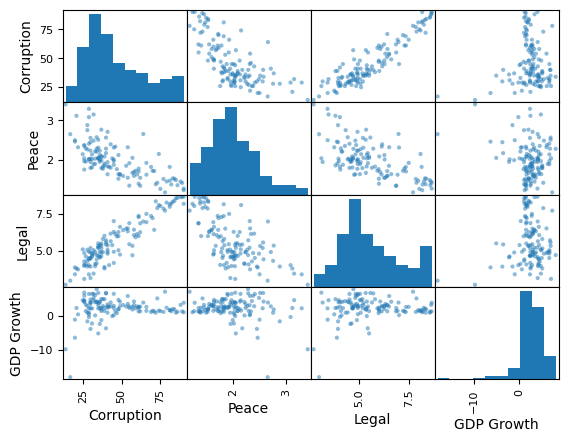

In [171]:
pd.plotting.scatter_matrix(indicators_df)

We can see that in particular the legal, peace, and corruption indicators are fairly strongly correlated, while GDP growth seems to have little correlation with any of the other three. As well, we can slightly see three clusters in the Legal and GDP Growth scatterplot. Finally, we see a few outliers especially in the GDP Growth plots.

<h3>Task 1b: Correlation Matrix</h3>
We then create a table which displays the correlation between each pair of features.

In [4]:
indicators_df.corr(numeric_only=True)

,Corruption,Peace,Legal,GDP Growth
Corruption,1.000000,-0.700477,0.923589,0.100742
Peace,-0.700477,1.000000,-0.651961,-0.200639
Legal,0.923589,-0.651961,1.000000,0.118305
GDP Growth,0.100742,-0.200639,0.118305,1.000000


We can see that the legal risk and corruption indicators are the most strongly correlated (positive), which makes intuitive sense because one would expect greater protection to go hand in hand with trustable governments.

<h3>1c: Standardization</h3>
Supposing we ran K-Means on the raw data, the corruption feature would dominate the distance calculations since it has the greatest range in the data (0 to 100). In other words, corruption has the greatest influence on which cluster each point belongs to.

<h2>Problem 2: K-Means Clustering</h2>
<h3>Data Preparation</h3>
First we convert the dataframe of the csv above into a feature matrix, and standardize the features.

In [175]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# convert dataframe to numpy array
X = indicators_df[['Corruption','Peace','Legal','GDP Growth']].values

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# np.set_printoptions(suppress=True, precision=5)
# print(X_scaled)
# X_scaled_df = pd.DataFrame(data = X_scaled, columns = ['Corruption', 'Peace', 'Legal', 'GDP Growth'])

<h3>Task 2a: The Elbow Method</h3>


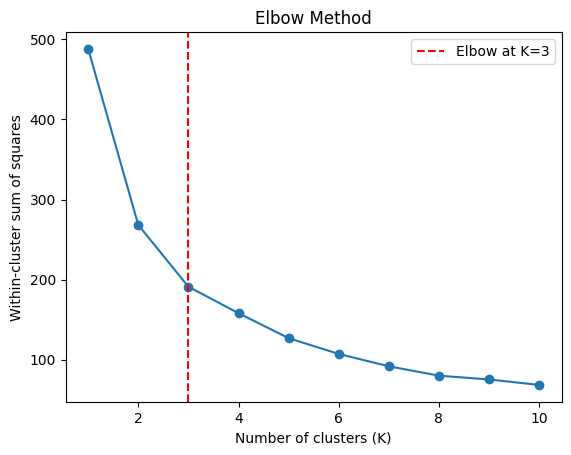

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Fit K-Means from K = 1 to 10
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=1000)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# plot
fig, ax = plt.subplots()
ax.plot(K_range, wcss, 'o-')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Within-cluster sum of squares')
ax.set_title('Elbow Method')
ax.axvline(x=3, color='red', linestyle='--', label='Elbow at K=3')
ax.legend()
plt.show()


Here we see an appropriate elbow at K = 3 - in other words, grouping into 3 clusters seems to make the most sense. This is because cramming in more clusters does not offer us much more decrease in WCSS (our measure of error) and only risks overfitting noise.

<h3>Task 2b: K-Means</h3>
Now we fit a K-Means model to the data, K=3. We will take the best out of 10 runs with 1000 iterations per run.

In [170]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter = 1000)
cluster_labels = kmeans.fit_predict(X_scaled)
ccenters_df = pd.DataFrame(data = kmeans.cluster_centers_, columns = ['Corruption', 'Peace', 'Legal', 'GDP Growth'])
ccenters_df.index.name = 'Cluster'
ccenters_df


,Corruption,Peace,Legal,GDP Growth
Cluster,,,,
0,-0.479569,0.263309,-0.435100,0.375879
1,1.231352,-0.979187,1.165956,0.006201
2,-1.027467,1.352217,-1.059033,-1.720105


The cluster centers are outputted above. Note that:
- A lower standardized corruption index indicates *more* corruption on average.
- A lower standardized peace index indicates less *conflict* on average.
<br><br>

| Cluster | Interpretation |
|---:|---|
| 0 | Highest average GDP growth, government not as clean, not as peaceful, not as much protection of property rights |
| 1 | Most devoid of corruption, most peaceful, most protection of property rights, but almost no GDP growth on average |
| 2 | Lowest average GDP growth, most corrupt, least peaceful, least protection of property rights |

We can consider cluster 1 as the group of "ideal" countries to live in, although its average GDP growth is dwarfed by that of cluster 0. Cluster 2 can be considered as having the least desirable characteristics.

<h3>Task 2c: Listing countries per cluster</h3>
Here we actually observe which countries fall into which cluster.

In [138]:
countries = indicators_df.index.values
km_clusters = []
for i in range(3):
    km_clusters.append(list(countries[cluster_labels == i]))
    print(f"Countries in cluster {i}:\n{km_clusters[i]}\n")

Countries in cluster 0:
['Albania', 'Algeria', 'Armenia', 'Bahrain', 'Bangladesh', 'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Bulgaria', 'Cameroon', 'China', 'Colombia', 'Croatia', 'Cyprus', 'Dominican Republic', 'Egypt', 'El Salvador', 'Ethiopia', 'Gabon', 'Georgia', 'Ghana', 'Greece', 'Guatemala', 'Honduras', 'India', 'Indonesia', 'Iran', 'Israel', 'Italy', 'Jamaica', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mexico', 'Moldova', 'Montenegro', 'Morocco', 'Mozambique', 'Nepal', 'Nicaragua', 'Oman', 'Pakistan', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Romania', 'Rwanda', 'Saudi Arabia', 'Senegal', 'Serbia', 'Sierra Leone', 'South Africa', 'Sri Lanka', 'Tanzania', 'Thailand', 'The FYR of Macedonia', 'Tunisia', 'Turkey', 'Uganda', 'Vietnam', 'Zambia']

Countries in cluster 1:
['Australia', 'Austria', 'Belgium', 'Botswana', 'Canada', 'Chile', 'Costa Rica', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germa

Just as mentioned before, cluster 1 contains nations that people tend to associate with higher qualities of life, like Iceland, Norway, and Switzerland. In particular, this cluster is very similar to the IMF's defined group of [advanced economies](https://www.imf.org/en/publications/weo/weo-database/2023/april/groups-and-aggregates), as well as containing at least the top 26 countries of the [Human Development Index](https://en.wikipedia.org/wiki/List_of_countries_by_Human_Development_Index).

Cluster 0 also contains a few nations from the IMF advanced economies list. This makes sense given that the most notable characteristic for cluster 0 is its high average GDP growth. I am also not surprised to see countries like China and India in this list, both also exhibiting significant economic growth in recent years despite not being defined as an "advanced economy".

There is not much to say regarding cluster 2, although I find it interesting that Russia and Ukraine are listed in this cluster. Of course, their peace index should be relatively high considering their ongoing conflict, but I did not expect their economic growth to be below average either.

<h3> Task 2d: Silhouette Score </h3>
As an alternative to the elbow method, we plot the silhouette scores of K = 2 to 10 clusters.

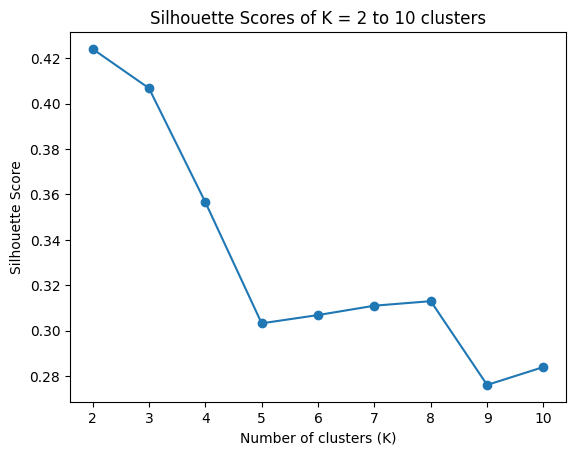

In [71]:
from sklearn.metrics import silhouette_score

# Compute silhouette score for different K
silhouette_scores = []
K_range = range(2, 11)  # silhouette requires K >= 2

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=1000)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

fig, ax = plt.subplots()
ax.plot(K_range, silhouette_scores, 'o-')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Scores of K = 2 to 10 clusters')
# ax.axvline(x=4, color='red', linestyle='--', label='Best at K=4')
# ax.legend()
plt.show()

According to the silhoutte analysis, K = 2 is the optimal number of clusters. This does not agree with my interpretation of the result of the elbow method, where I chose K = 3. Given that the scores of K = 2 and K = 3 are not that different relative to the other clusters, I would stick to the elbow method in this case.

<h2>Problem 3: Hierarchical Clustering</h2>
<h3>Task 3a: Dendrogram</h3>
Here we use Ward's linkage to perform agglomerative hierarchical clustering on our data.

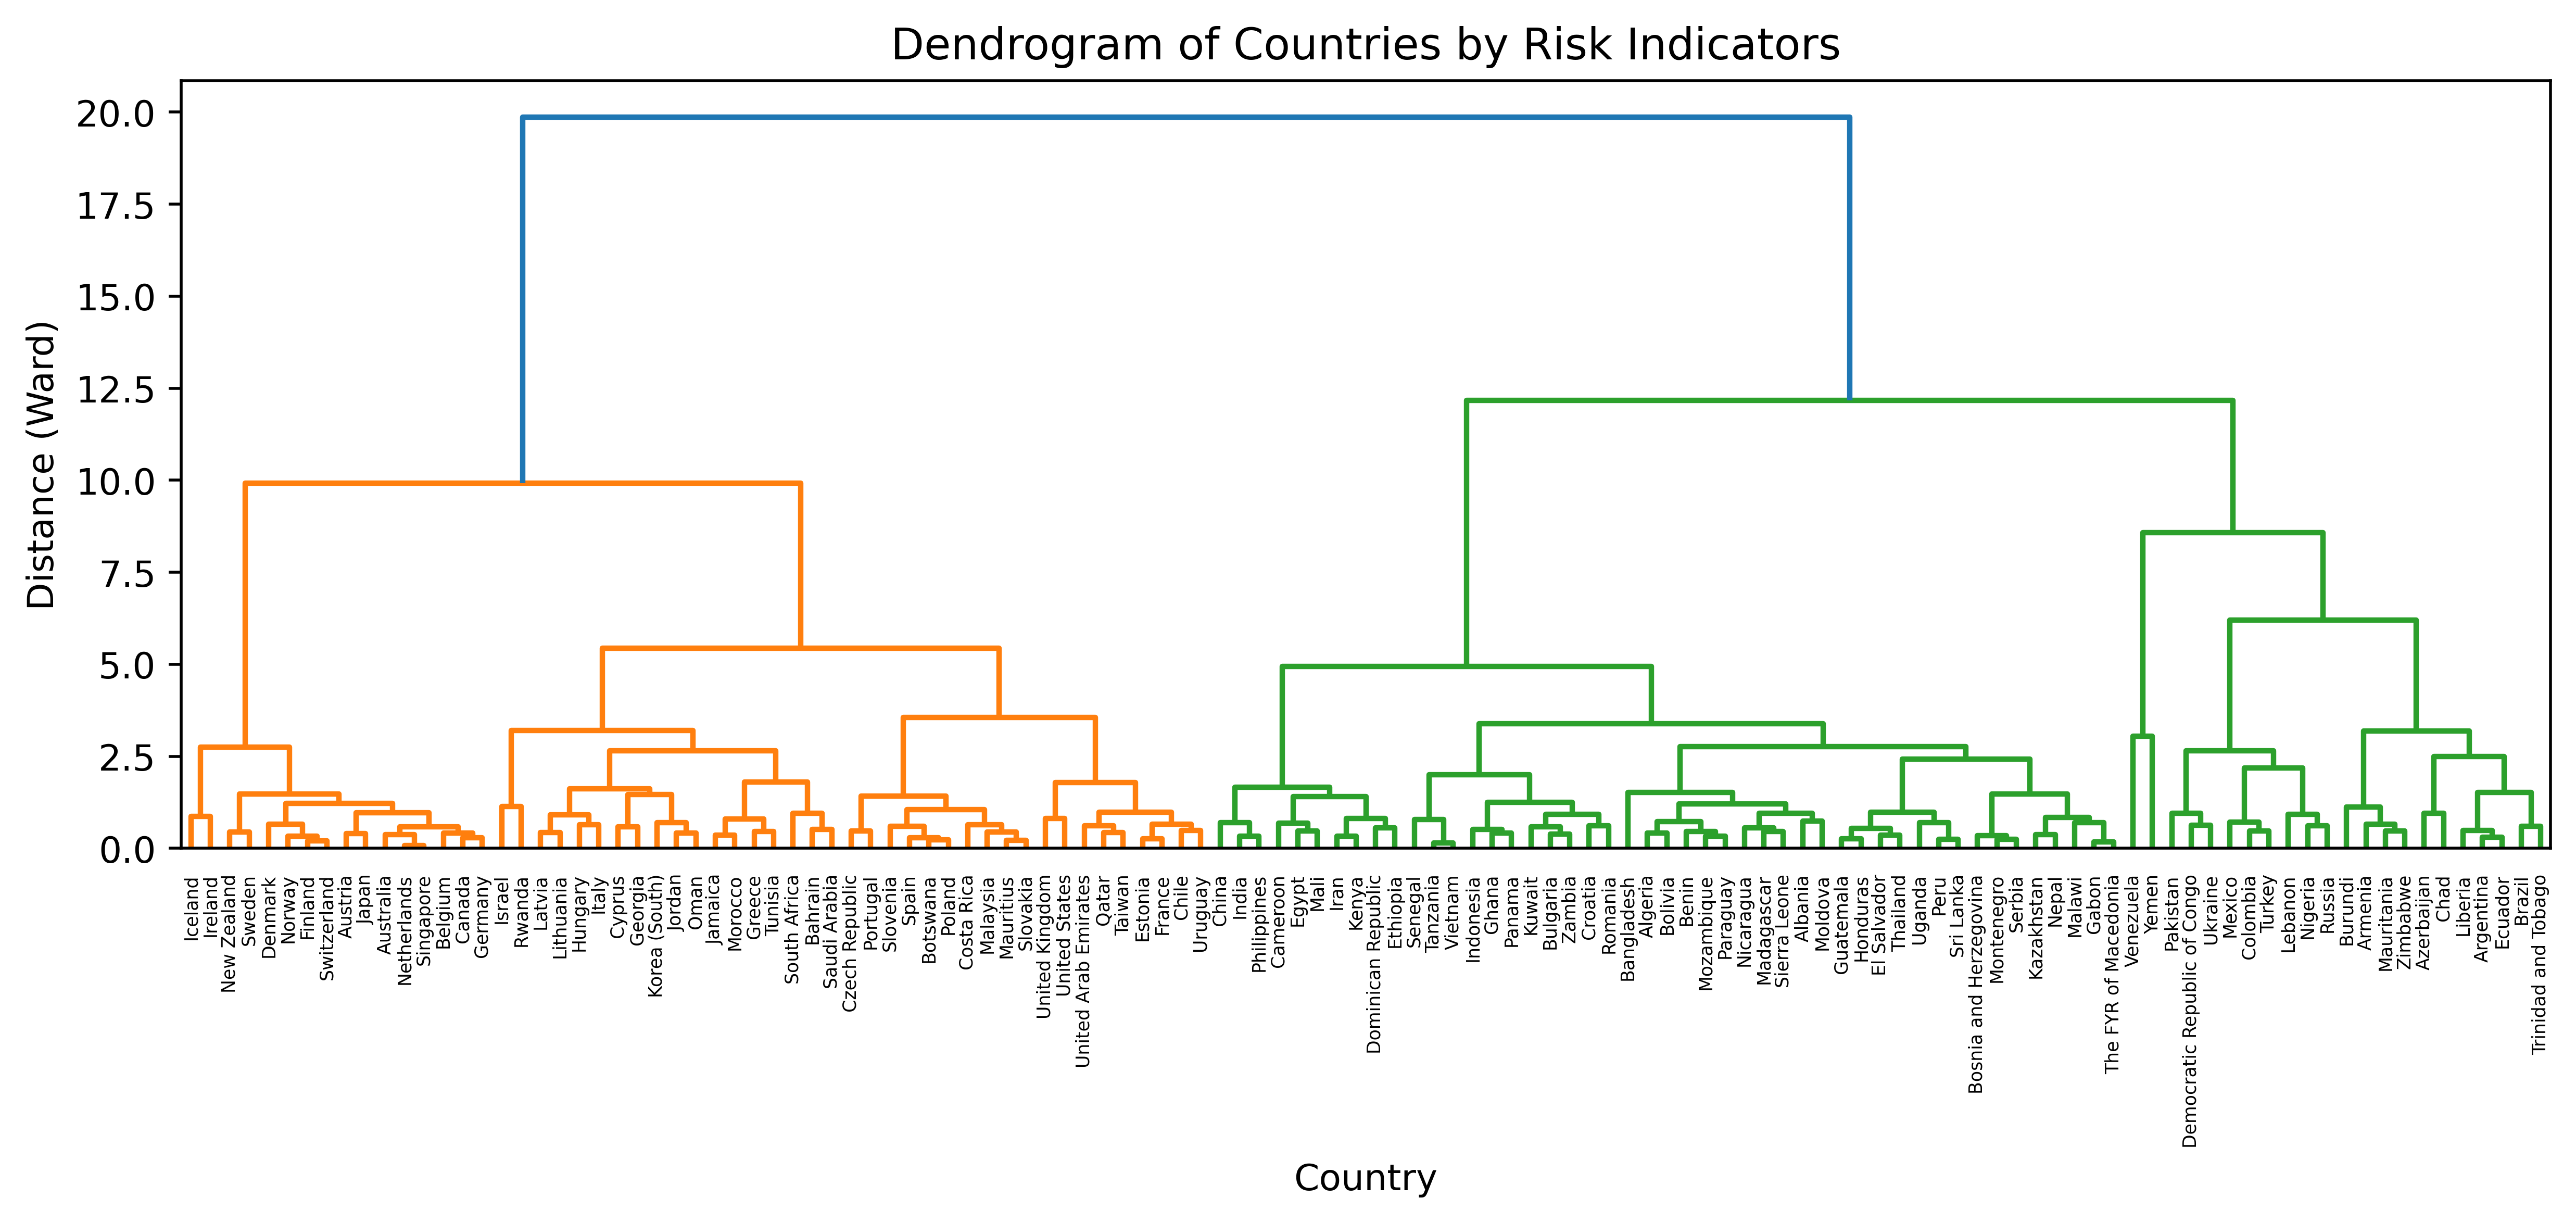

In [98]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Perform hierarchical clustering with Ward's method
Z = linkage(X_scaled, method='ward')

# Plot the dendrogram
fig, ax = plt.subplots()
fig.set_size_inches(10, 4.8)
fig.set_dpi(500)
dendrogram(Z, labels=countries, ax=ax, leaf_rotation=90)
ax.set_xlabel('Country')
ax.set_ylabel('Distance (Ward)')
ax.set_title('Dendrogram of Countries by Risk Indicators')
plt.tight_layout()
plt.show()

We can cut the height just above 10 to get the same amount of clusters as our K-means solution (3). The dendrogram does suggest that 4 or 5 clusters might be natural, as seen in how long the branches are from 5 to 4 to 3 clusters.

<h3>Task 3b: Cutting the dendrogram</h3>

In [184]:
cluster_labels_hc = fcluster(Z, t=3, criterion='maxclust')

# relabel clusters to align with K means clusters from before
hc_relabeled = np.zeros(no_of_countries, dtype=int)
for i in range(no_of_countries):
    match cluster_labels_hc[i]:
        case 1:
            hc_relabeled[i] = 1
        case 3:
            hc_relabeled[i] = 2

# find cluster centers
hc_centers = []
for i in range(3):
    hc_centers.append(np.mean(X_scaled[hc_relabeled == i], axis = 0))
print("Hierarchical Cluster Centers:")
print(f"{pd.DataFrame(data = hc_centers, columns = ['Corruption', 'Peace', 'Legal', 'GDP Growth'])}\n")

# create a 3x3 matrix to sort countries by their cluster placement in both the K-Means and hierarchical methods
cluster_matrix = np.zeros(shape = (3, 3), dtype=list)

# initialize matrix
for i in range(3):
    print(f"Countries in Hierarchical Cluster {i}:") # take advantage of this loop to print out hierarchical clusters
    print(f"{list(countries[hc_relabeled == i])}\n")
    for j in range(3):
        cluster_matrix[i][j] = []

# sort countries
for i in range(no_of_countries):
    cluster_matrix[hc_relabeled[i]][cluster_labels[i]].append(countries[i])

same_clustered_countries = len(cluster_matrix[0][0]) + len(cluster_matrix[1][1]) + len(cluster_matrix[2][2])
print(f"{same_clustered_countries} of {no_of_countries} countries were placed in the same cluster as in the K-Means method.")

# Find countries placed in different clusters
for i in range(3):
    for j in range(3):
        if i != j and cluster_matrix[i][j]:
            print(f"\nCountries in K-Means Cluster {j} placed in Hierarchical Cluster {i}:\n{cluster_matrix[i][j]}")

Hierarchical Cluster Centers:
   Corruption     Peace     Legal  GDP Growth
0   -0.616781  0.108662 -0.599512    0.593353
1    0.923594 -0.633942  0.922256   -0.014315
2   -0.907355  1.295081 -0.941022   -1.233132

Countries in Hierarchical Cluster 0:
['Albania', 'Algeria', 'Bangladesh', 'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Bulgaria', 'Cameroon', 'China', 'Croatia', 'Dominican Republic', 'Egypt', 'El Salvador', 'Ethiopia', 'Gabon', 'Ghana', 'Guatemala', 'Honduras', 'India', 'Indonesia', 'Iran', 'Kazakhstan', 'Kenya', 'Kuwait', 'Madagascar', 'Malawi', 'Mali', 'Moldova', 'Montenegro', 'Mozambique', 'Nepal', 'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Romania', 'Senegal', 'Serbia', 'Sierra Leone', 'Sri Lanka', 'Tanzania', 'Thailand', 'The FYR of Macedonia', 'Uganda', 'Vietnam', 'Zambia']

Countries in Hierarchical Cluster 1:
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Botswana', 'Canada', 'Chile', 'Costa Rica', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia',

We can see that all disjoint countries (different clusters per method) originate from K-Cluster 0 and are placed in either H-Cluster 1 or 2. Interpreting each case of disjunction separately,
1. Countries placed in H-Cluster 1 may have better living standards / government cleanliness and less GDP growth than average within K-Cluster 0, allowing them to be identified as Cluster 1 countries in the hierarchical method.
2. Countries placed in H-Cluster 2 may have worse living standards, more corruption, and also less GDP growth than average within K-Cluster 0, allowing them to be identified as Cluster 2 countries in the hiearchical method.

In the end, this suggests that Clusters 1 and 2 are relatively more different to each other than they are to Cluster 0, which can be considered as a sort of middle ground between the first two.

<h3>3c: Tradeoffs</h3>

The obvious advantage to hierarchical clustering is how easy it is to view the different possibilities of cluster numbers, and being able to commit to a specific K later on. However, this also makes it relatively slow and computationally expensive, especially compared to K-Means which in in the [scikit documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) is described as "one of the fastest clustering algorithms available". In this example fitting with either method does not take more than a second to compute, but on larger sets of data this can become more significant.

<h2>Problem 4: Interpretation and Investment Implications</h2>
<h3>4a: Risk Ranking</h3>
We now rank the clusters by investment risk, in order from least to most risky:

1. Cluster 1
2. Cluster 0
3. Cluster 2

This ranking maps 1 to 1 for each cluster center's rank when sorted by any of the first three indicators (corruption index, peace, protection of property). We deliberately ignore average GDP growth in this case since it is difficult to establish a relationship between it and investment failure. However, the fact that cluster 0 has higher average GDP growth and ranks as riskier than cluster 1 makes sense from the perspective of market theory intuition.

<h3>4b: Insights</h3>
Given that cluster 2 is ranked as the riskiest and also has the lowest GDP growth, we can consider it the furthest from the risk-return efficient frontier compared to the other two clusters. The allocation of investment funds will then boil down to clusters 0 and 1. Investors who are less averse to risk may choose to allocate more funds to cluster 0, and vice-versa. However, there are limitations to relying solely on these four indicators. These clusters give no information on the distribution of sectors within each nation's economy. For example, a country in cluster 2 could be experiencing a significant boom in a specific sector, even if its overall average indicators may present themselves as undesirable.

<h3>Disclaimers</h3>
Generative AI was used at some points during this report. Specifically when Googling certain code syntaxes, Google Gemini 3 would annoyingly automatically display its own answer (and even more annoyingly so, it was often correct).